HOSPITAL READMISSION PREDICTION

First 5 rows:
   age  heart_rate  systolic_bp  prior_visits  length_of_stay  diagnosis_code  \
0   69        56.4         88.9             4               3               4   
1   32        83.6        144.2             4              13               2   
2   89        59.4        137.8             4               7               0   
3   78        71.9        119.8             2               6               2   
4   38        69.2         99.5             1              12               0   

   diabetes  readmitted  
0         0           1  
1         0           0  
2         1           1  
3         0           0  
4         1           0  

Dataset Shape:
(300, 8)

Class Distribution:
readmitted
0    215
1     85
Name: count, dtype: int64

Training samples: 240
Testing samples : 60

Model training completed.

MODEL PERFORMANCE

ROC-AUC Score: 0.673

Confusion Matrix:
[[38  5]
 [14  3]]

True Negatives : 38
False Positives: 5
False Negatives: 14

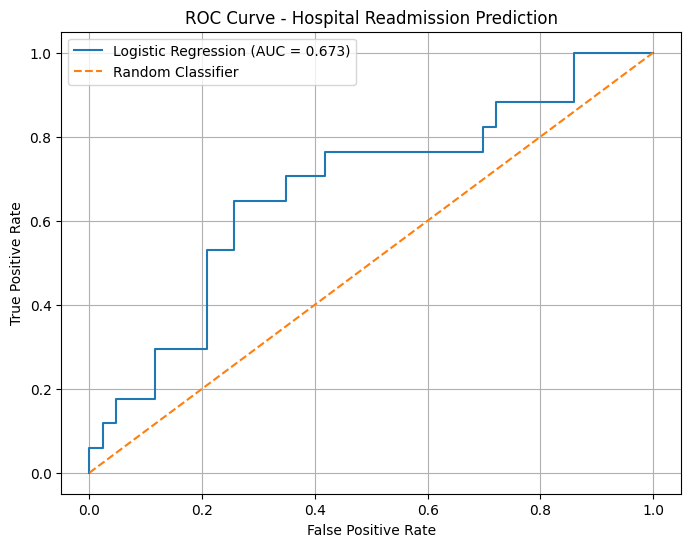


THRESHOLD ANALYSIS

Threshold: 0.30
TP: 11 | FP: 13 | FN: 6 | TN: 30
Sensitivity: 0.647
Specificity: 0.698

Threshold: 0.40
TP: 5 | FP: 9 | FN: 12 | TN: 34
Sensitivity: 0.294
Specificity: 0.791

Threshold: 0.50
TP: 3 | FP: 5 | FN: 14 | TN: 38
Sensitivity: 0.176
Specificity: 0.884

Threshold: 0.60
TP: 3 | FP: 2 | FN: 14 | TN: 41
Sensitivity: 0.176
Specificity: 0.953

Threshold: 0.70
TP: 0 | FP: 0 | FN: 17 | TN: 43
Sensitivity: 0.000
Specificity: 1.000

FEATURE COEFFICIENTS
       Feature  Coefficient  Absolute_Coefficient
  prior_visits     0.653621              0.653621
           age     0.365962              0.365962
   systolic_bp     0.247377              0.247377
      diabetes     0.184863              0.184863
    heart_rate    -0.117574              0.117574
diagnosis_code     0.088345              0.088345
length_of_stay     0.004855              0.004855

CASE STUDY SUMMARY

Problem:
Predict 30-day hospital readmission risk.

Model:
Logistic Regression

Regularization:
L2 Re

In [1]:
# ============================================================
# CASE STUDY 1: HOSPITAL READMISSION PREDICTION
# Logistic Regression with L2 Regularization
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. CREATE SYNTHETIC PATIENT DATASET
# ============================================================
# In a real project, you can replace this section with:
#
# df = pd.read_csv("patient_records.csv")
#
# This synthetic dataset is created only for demonstration.

np.random.seed(42)

n = 300

df = pd.DataFrame({
    "age": np.random.randint(18, 90, n),

    "heart_rate": np.random.normal(78, 12, n).round(1),

    "systolic_bp": np.random.normal(125, 18, n).round(1),

    "prior_visits": np.random.poisson(2.5, n),

    "length_of_stay": np.random.randint(1, 15, n),

    "diagnosis_code": np.random.randint(0, 5, n),

    "diabetes": np.random.randint(0, 2, n)
})


# ============================================================
# 2. CREATE READMISSION TARGET
# ============================================================
# This creates a synthetic probability of readmission.
# It is NOT real clinical data.

risk_score = (
    -3.0
    + 0.025 * (df["age"] - 50)
    + 0.35 * df["prior_visits"]
    + 0.10 * df["length_of_stay"]
    + 0.35 * df["diabetes"]
    + 0.25 * (df["diagnosis_code"] >= 3)
    + np.random.normal(0, 0.8, n)
)

probability = 1 / (1 + np.exp(-risk_score))

df["readmitted"] = np.random.binomial(1, probability)


# ============================================================
# 3. DISPLAY DATA
# ============================================================

print("=" * 60)
print("HOSPITAL READMISSION PREDICTION")
print("=" * 60)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nClass Distribution:")
print(df["readmitted"].value_counts())


# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("readmitted", axis=1)

y = df["readmitted"]


# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================
# 80% training data
# 20% testing data
#
# stratify=y keeps the class distribution similar
# in both training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 6. FEATURE SCALING
# ============================================================
# StandardScaler transforms the features so that they have
# approximately mean = 0 and standard deviation = 1.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# 7. LOGISTIC REGRESSION WITH L2 REGULARIZATION
# ============================================================
# L2 is the default regularization for LogisticRegression.
#
# C controls the strength of regularization:
# Smaller C  -> stronger regularization
# Larger C   -> weaker regularization

model = LogisticRegression(
    C=1.0,
    solver="liblinear",
    random_state=42
)


# ============================================================
# 8. TRAIN THE MODEL
# ============================================================

model.fit(X_train_scaled, y_train)

print("\nModel training completed.")


# ============================================================
# 9. PREDICT READMISSION PROBABILITIES
# ============================================================
# Instead of directly predicting 0/1, we obtain the probability
# that each patient will be readmitted.

y_prob = model.predict_proba(X_test_scaled)[:, 1]


# ============================================================
# 10. DEFAULT CLASSIFICATION THRESHOLD
# ============================================================
# If probability >= 0.50 -> Readmitted
# Otherwise -> Not Readmitted

threshold = 0.50

y_pred = (y_prob >= threshold).astype(int)


# ============================================================
# 11. ROC-AUC SCORE
# ============================================================

roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"\nROC-AUC Score: {roc_auc:.3f}")


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Readmitted",
            "Readmitted"
        ],
        zero_division=0
    )
)


# ============================================================
# 14. CLINICAL COST ANALYSIS
# ============================================================
# These are illustrative costs.
#
# False Negative:
# Model says patient is low risk,
# but patient is actually readmitted.
#
# False Positive:
# Model says patient is high risk,
# but patient is not readmitted.
#
# In healthcare, a false negative can potentially be more
# serious because a high-risk patient may miss follow-up care.

FALSE_NEGATIVE_COST = 10
FALSE_POSITIVE_COST = 2

fn_cost = fn * FALSE_NEGATIVE_COST

fp_cost = fp * FALSE_POSITIVE_COST

total_cost = fn_cost + fp_cost


print("\n" + "=" * 60)
print("CLINICAL COST ANALYSIS")
print("=" * 60)

print(f"\nFalse Negative Cost: {fn_cost}")
print(f"False Positive Cost: {fp_cost}")
print(f"Total Illustrative Cost: {total_cost}")

print("\nClinical Interpretation:")

print(
    "\nFalse Negative:"
    "\nThe model predicts that a patient is not at high risk,"
    "\nbut the patient is actually readmitted."
)

print(
    "\nFalse Positive:"
    "\nThe model predicts that a patient is at high risk,"
    "\nbut the patient is not readmitted."
)

print(
    "\nIn this case study, false negatives are assigned a higher"
    "\ncost because missing a high-risk patient could result in"
    "\nmissed follow-up or preventive intervention."
)

print(
    "\nNOTE: The cost values used here are illustrative and are"
    "\nnot actual medical or hospital costs."
)


# ============================================================
# 15. ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Hospital Readmission Prediction"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 16. THRESHOLD ANALYSIS
# ============================================================
# We test different probability thresholds.
#
# Lower threshold:
# - More patients are classified as high-risk
# - Usually increases sensitivity
# - Can increase false positives
#
# Higher threshold:
# - Fewer patients are classified as high-risk
# - Usually reduces false positives
# - Can increase false negatives

print("\n" + "=" * 60)
print("THRESHOLD ANALYSIS")
print("=" * 60)

thresholds_to_test = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

for threshold in thresholds_to_test:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    ).ravel()

    # Sensitivity = TP / (TP + FN)
    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    # Specificity = TN / (TN + FP)
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    print(
        f"\nThreshold: {threshold:.2f}"
    )

    print(
        f"TP: {tp} | "
        f"FP: {fp} | "
        f"FN: {fn} | "
        f"TN: {tn}"
    )

    print(
        f"Sensitivity: {sensitivity:.3f}"
    )

    print(
        f"Specificity: {specificity:.3f}"
    )


# ============================================================
# 17. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================
# Coefficients indicate the direction of association:
#
# Positive coefficient:
# Higher feature value -> higher predicted readmission risk
#
# Negative coefficient:
# Higher feature value -> lower predicted readmission risk
#
# The features were standardized before training.

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("\n" + "=" * 60)
print("FEATURE COEFFICIENTS")
print("=" * 60)

print(
    coefficients.to_string(index=False)
)


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("CASE STUDY SUMMARY")
print("=" * 60)

print("\nProblem:")
print("Predict 30-day hospital readmission risk.")

print("\nModel:")
print("Logistic Regression")

print("\nRegularization:")
print("L2 Regularization")

print(f"\nROC-AUC:")
print(f"{roc_auc:.3f}")

print("\nEvaluation Metrics:")
print("- ROC-AUC")
print("- Confusion Matrix")
print("- Precision")
print("- Recall")
print("- F1-score")
print("- Sensitivity")
print("- Specificity")

print("\nAdditional Analysis:")
print("- False Positive vs False Negative clinical cost")
print("- Decision threshold analysis")
print("- Feature coefficient interpretation")

print(
    "\nImportant:"
    "\nThis dataset is synthetic and is intended only for"
    "\neducational demonstration. It should not be used for"
    "\nactual clinical decision-making."
)